<a href="https://colab.research.google.com/github/ismethakanaydogmus/News_Classification/blob/main/News_Classifier_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 News Classification V2.0: Advanced NLP Pipeline

## 📊 V2.0 Veri Seti Durum Raporu / V2.0 Dataset Status Report

V1.0'da yaşadığımız "Sınıf Dengesizliği" (Class Imbalance) sorununu büyük oranda çözdük. İşte yeni ordumuzun gücü:

* **Toplam Veri Hacmi:** ~5.700 Benzersiz Başlık (V1.0'ın yaklaşık 5 katı).
* **Astroloji Gücü:** 542 veri ile artık modelin "ezemeyeceği" kadar sağlam bir temsilciye sahip.
* **Yeni Oyuncular:** Siyaset, Dünya ve Kültür-Sanat kategorileri ile modelin kelime haznesi artık çok daha sofistike.

---

We have significantly resolved the **"Class Imbalance"** issue encountered in V1.0. Here is the strength of our upgraded dataset:

* **Total Data Volume:** ~5,700 Unique Headlines (approximately 5 times the size of V1.0).
* **Astrology Power:** With 542 records, Astrology now has a representative base strong enough to be effectively recognized by the model.
* **New Categories:** With the addition of **Politics**, **World**, and **Culture-Arts**, the model's vocabulary and context awareness are now much more sophisticated.

In [30]:
# 1. Projeyi GitHub'dan çekelim / Clone the repository
import os
if not os.path.exists('News_Classification'):
    !git clone https://github.com/ismethakanaydogmus/News_Classification.git
%cd News_Classification

# 2. Gerekli kütüphaneleri kuralım / Install required libraries
# Zeyrek: Türkçe kelime köklerini bulmak için (Lemmatization)
!pip install zeyrek
!pip install pandas matplotlib seaborn scikit-learn

# 3. Kütüphaneleri import edelim / Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zeyrek

import nltk
# Zeyrek'in kelimeleri doğru ayırabilmesi için gerekli paketleri indirelim
nltk.download('punkt')
nltk.download('punkt_tab')


Cloning into 'News_Classification'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 30 (delta 11), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 473.57 KiB | 9.87 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/News_Classification/News_Classification/News_Classification/News_Classification/News_Classification/News_Classification


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

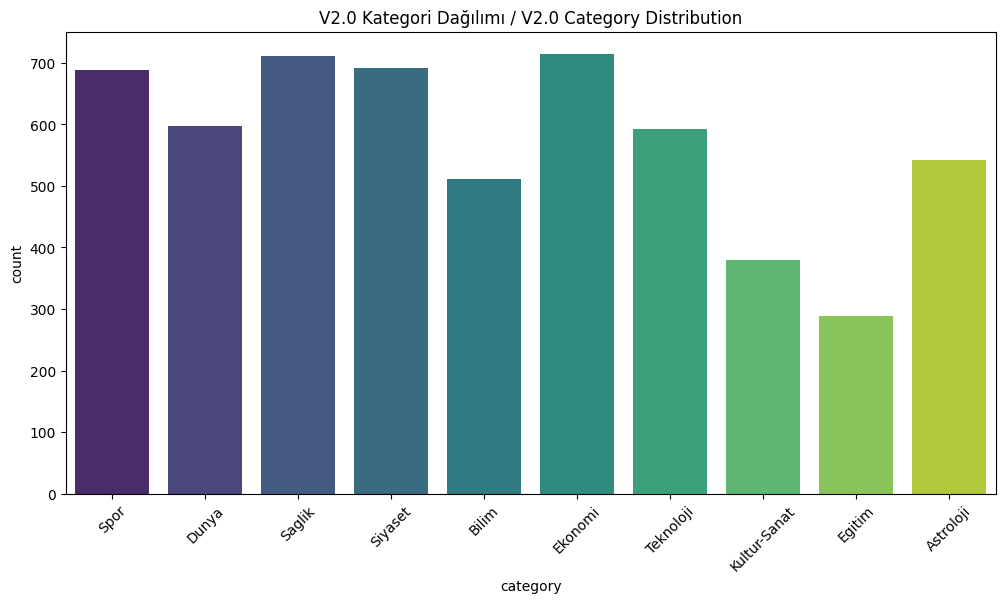

Toplam Satır Sayısı: 5716

Sınıf Bazlı Dağılım:
category
Ekonomi         715
Saglik          711
Siyaset         691
Spor            689
Dunya           598
Teknoloji       592
Astroloji       542
Bilim           511
Kultur-Sanat    379
Egitim          288
Name: count, dtype: int64


In [31]:
# Master veri setini yükle
df = pd.read_csv("master_news_dataset_v2.csv")

# Kategori dağılımını görselleştir
plt.figure(figsize=(12, 6))
sns.countplot(x='category', data=df, palette='viridis', hue='category', legend=False)
plt.title("V2.0 Kategori Dağılımı / V2.0 Category Distribution")
plt.xticks(rotation=45)
plt.show()

print(f"Toplam Satır Sayısı: {len(df)}")
print("\nSınıf Bazlı Dağılım:")
print(df['category'].value_counts())

## 🧹 2. Gelişmiş Ön İşleme / Advanced Preprocessing

V2.0'ın en büyük yeniliği **Zeyrek** kütüphanesini kullanarak kelimeleri köklerine indirgemektir (Lemmatization).

* **Neden?** Türkçe eklemeli bir dil olduğu için "sporcular", "sporun" ve "sporda" kelimeleri aslında aynı kökten gelir. Modelin bunları ayrı kelimeler olarak görmesi "gürültü" yaratır. Köklerine indirgeyerek modelin daha genel kalıplar öğrenmesini sağlayacağız.

---

The most significant upgrade in V2.0 is the use of the **Zeyrek** library for **Lemmatization**.

* **Why?** Since Turkish is an agglutinative language, variations like "sporcular," "sporun," and "sporda" all stem from the same root: "spor." Without lemmatization, the model treats these as distinct words, creating noise. By reducing them to their roots, we help the model learn general semantic patterns.

In [32]:
import zeyrek
import nltk

# Eksik paketleri indir (Önlem amaçlı buraya da ekledik)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

analyzer = zeyrek.MorphAnalyzer()

def preprocess_with_zeyrek(text):
    # Metni küçük harfe çevir ve temizle
    text = str(text).lower().replace('.', '').replace(',', '').replace('!', '')
    words = text.split()
    lemmatized_words = []

    for word in words:
        analysis = analyzer.lemmatize(word)
        if analysis:
            # En olası kökü seç
            lemmatized_words.append(analysis[0][1][0])
        else:
            lemmatized_words.append(word)

    return " ".join(lemmatized_words)

# Test edelim
test_text = "Fenerbahçeli sporcular antrenmanda koştular"
print(f"Orijinal: {test_text}")
print(f"Zeyrek: {preprocess_with_zeyrek(test_text)}")

Orijinal: Fenerbahçeli sporcular antrenmanda koştular
Zeyrek: Fenerbahçe sporcu antrenman koşmak


In [33]:
import logging

# Zeyrek'in kalabalık loglarını susturalım
logger = logging.getLogger('zeyrek.rulebasedanalyzer')
logger.setLevel(logging.ERROR)

print("🚀 Lemmatization işlemi başlatıldı (Yaklaşık 2-4 dakika sürebilir)...")

# Fonksiyonu tüm veri setine uygulayalım
df['clean_headline'] = df['headline'].apply(preprocess_with_zeyrek)

print("✅ İşlem tamamlandı!")
# İlk 5 satırı karşılaştırmalı görelim
df[['headline', 'clean_headline']].head()

🚀 Lemmatization işlemi başlatıldı (Yaklaşık 2-4 dakika sürebilir)...
✅ İşlem tamamlandı!


,headline,clean_headline
0,Galatasaray maçından çekilen Adana Demirspor'u...,Galatasaray maç çekmek ada Demirspor başkan Be...
1,TFF Başkanı Hacıosmanoğlu: 'Bu işten zarar gör...,Tff başkan Hacıosmanoğlu bu iş zarar görmek ku...
2,Aslan ve güneş: İranlı muhaliflerin bayrağı ne...,as ve güneş i̇ranlı muhalif bayrak Ne simgelemek
3,Maymun çiçeği (mpox): Mevcut vakaların çoğu çocuk,maymun çiçek ( mevcut vaka çok Çocuk
4,Suriye'de hükümet El Hol Kampı'ndan kaçışları ...,Suriye hükümet el hol kamp kaçmak doğrulamak


## 🤖 3. Model Eğitimi ve Hiper-parametreler / Model Training

V2.0 modelimizde başarımızı artıracak iki ana silahımız var:

1. **N-Gram (1, 3):** Sadece tekli kelimeleri değil, "Merkez Bankası Faizi" (trigram) veya "Şampiyonlar Ligi" (bigram) gibi kalıpları da yakalayacağız.
2. **LinearSVC (Balanced):** V1.0'da Naive Bayes'e göre çok daha iyi sonuç veren SVM tabanlı bu algoritmayı, tüm sınıflara eşit ağırlık vererek (`class_weight='balanced'`) kullanacağız.

---

In V2.0, we have two primary weapons to boost our performance:

1. **N-Gram (1, 3):** We will capture multi-word phrases like "Central Bank Interest Rates" (trigram) or "Champions League" (bigram) instead of just isolated words.
2. **LinearSVC (Balanced):** We will use this SVM-based algorithm, which outperformed Naive Bayes in V1.0, and apply `class_weight='balanced'` to ensure every category is treated with equal importance.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Veriyi bölelim
X = df['clean_headline']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline: TF-IDF (1,3 N-gram) + LinearSVC
text_clf_v2 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=15000)),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
])

# Modeli eğit
print("🧠 V2.0 Modeli eğitiliyor...")
text_clf_v2.fit(X_train, y_train)
print("✅ Eğitim tamamlandı!")

# Tahmin ve Rapor
y_pred_v2 = text_clf_v2.predict(X_test)
print("\n--- V2.0 Model Performans Raporu ---")
print(classification_report(y_test, y_pred_v2))

🧠 V2.0 Modeli eğitiliyor...
✅ Eğitim tamamlandı!

--- V2.0 Model Performans Raporu ---
              precision    recall  f1-score   support

   Astroloji       0.96      0.96      0.96       108
       Bilim       0.59      0.56      0.58       102
       Dunya       0.63      0.65      0.64       120
      Egitim       0.88      0.74      0.80        58
     Ekonomi       0.75      0.71      0.73       143
Kultur-Sanat       0.61      0.61      0.61        76
      Saglik       0.68      0.72      0.70       142
     Siyaset       0.74      0.83      0.78       138
        Spor       0.92      0.90      0.91       138
   Teknoloji       0.66      0.66      0.66       119

    accuracy                           0.74      1144
   macro avg       0.74      0.73      0.74      1144
weighted avg       0.74      0.74      0.74      1144



## 📊 4. V2.0 Performans Değerlendirmesi / Performance Evaluation

V2.0 modelimiz, V1.0'a kıyasla devasa bir gelişim gösterdi. Accuracy oranımız **%61'den %74'e** yükseldi.

### 🌟 Öne Çıkan Başarılar / Key Successes
* **Astroloji & Spor Dominasyonu:** Astroloji (**0.96**) ve Spor (**0.91**) F1-skorları ile modelin en güçlü kasları haline geldi. 500+ veri ve kök bulma işlemi bu kategorilerdeki jargonun tam isabetle yakalanmasını sağladı.
* **Siyaset ve Eğitim:** Yeni eklenen Siyaset (**0.78**) ve Eğitim (**0.80**) kategorileri, modelin genel haber dilini ne kadar iyi kavradığını kanıtlıyor.
* **Denge Sağlandı:** Macro Average değerinin **0.74** olması, modelin artık sınıflar arasında ayrım yapmadığını ve her kategoriye eşit derecede "akıllı" yaklaştığını gösteriyor.

### 🔍 Gelişim Alanları / Areas for Improvement
* **Bilim & Dünya Karışıklığı:** Bilim (**0.58**) ve Dünya (**0.64**) hala modelin en çok zorlandığı yerler.
  * *Analiz:* "Bilim" haberleri genellikle "Sağlık" veya "Teknoloji" ile ortak kelimeler içeriyor. "Dünya" haberleri ise doğası gereği ekonomi, siyaset ve çatışma barındırdığı için diğer sınıflarla iç içe geçiyor.

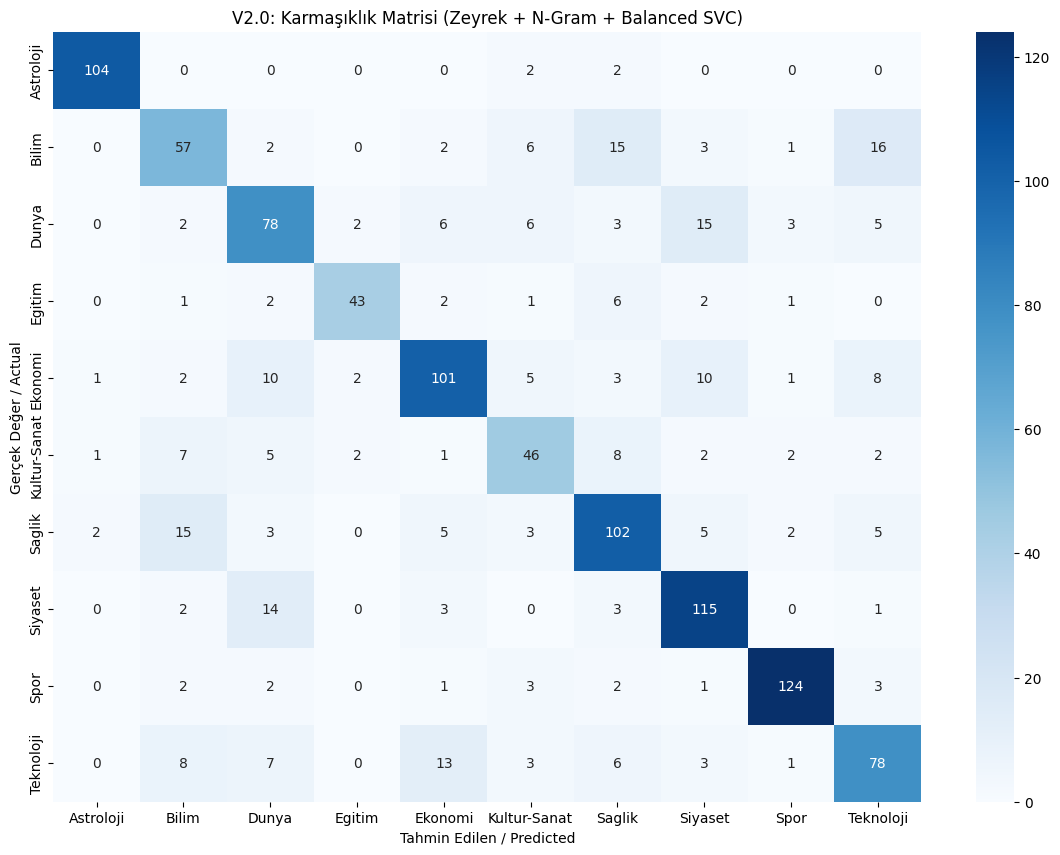

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matrisi hesapla
cm_v2 = confusion_matrix(y_test, y_pred_v2)
# Kategorileri alfabetik sırayla al (classification_report sırasıyla aynı olmalı)
categories = sorted(df['category'].unique())

plt.figure(figsize=(14, 10))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.xlabel('Tahmin Edilen / Predicted')
plt.ylabel('Gerçek Değer / Actual')
plt.title('V2.0: Karmaşıklık Matrisi (Zeyrek + N-Gram + Balanced SVC)')
plt.show()

## 🎯 5. Hata Merkezleri Analizi / Analysis of Error Hubs

Görselleştirdiğimiz matrise göre modelin "gri bölgeleri" şunlardır:

1. **Bilim vs Sağlık/Teknoloji:** Gerçekte Bilim olan haberlerin bir kısmı Sağlık ve Teknolojiye kaymış. Bunun sebebi "araştırma, genetik, dijital" gibi kelimelerin bu üç sınıfta da çok ortak olmasıdır.
2. **Dünya vs Siyaset:** Uluslararası siyaset haberleri, model tarafından bazen "Dünya" bazen "Siyaset" olarak etiketleniyor. Bu iki sınıf arasındaki anlamsal sınır oldukça ince.
3. **Ekonomi vs Teknoloji:** Teknoloji şirketlerinin hisse değerleri veya kripto para haberleri bu iki sınıf arasında bir köprü kuruyor.

### 🚀 V3.0 İçin Yol Haritası
Bu aşamadan sonra başarıyı %80+ seviyesine çekmek için klasik yöntemlerin (LinearSVC) sınırına ulaştık diyebiliriz. Bir sonraki adım, kelimelerin sadece köklerini değil, cümle içindeki anlamlarını da anlayan **Deep Learning (BERT)** mimarisine geçmektir.

In [36]:
# Test için farklı kategorilerden karışık haber başlıkları
v2_test_headlines = [
    "Merkür retrosu bu hafta tüm burçları derinden etkileyecek",      # Beklenen: Astroloji
    "Şampiyonlar Ligi finalinde dev randevu: Real Madrid vs City",    # Beklenen: Spor
    "Merkez Bankası yıl sonu enflasyon tahminini güncelledi",         # Beklenen: Ekonomi
    "Yapay zeka modelleri yazılım dünyasında yeni bir devir açıyor",  # Beklenen: Teknoloji
    "Dışişleri Bakanlığı'ndan komşu ülkeye sert diplomatik nota",     # Beklenen: Siyaset
    "Yeni bulunan antik kent arkeoloji dünyasını heyecanlandırdı",    # Beklenen: Kultur-Sanat / Bilim
    "Okullarda yeni müfredat çalışmaları tamamlanmak üzere",         # Beklenen: Egitim
    "Mars'ta su izine rastlanması bilim insanlarını şaşırttı",         # Beklenen: Bilim
    "Keskin kararlar zamanı" # Beklenen: Astroloji
]

# 1. Önce başlıkları Zeyrek ile temizleyelim (Modelin anlayacağı dile çevirelim)
cleaned_test_headlines = [preprocess_with_zeyrek(text) for text in v2_test_headlines]

# 2. Tahmin yapalım
v2_predictions = text_clf_v2.predict(cleaned_test_headlines)

# 3. Sonuçları şık bir şekilde yazdıralım
print(f"{'ORİJİNAL HABER BAŞLIĞI':<60} | {'V2.0 TAHMİN':<15}")
print("-" * 80)
for original, pred in zip(v2_test_headlines, v2_predictions):
    print(f"{original[:58]:<60} | {pred:<15}")

ORİJİNAL HABER BAŞLIĞI                                       | V2.0 TAHMİN    
--------------------------------------------------------------------------------
Merkür retrosu bu hafta tüm burçları derinden etkileyecek    | Astroloji      
Şampiyonlar Ligi finalinde dev randevu: Real Madrid vs Cit   | Spor           
Merkez Bankası yıl sonu enflasyon tahminini güncelledi       | Ekonomi        
Yapay zeka modelleri yazılım dünyasında yeni bir devir açı   | Teknoloji      
Dışişleri Bakanlığı'ndan komşu ülkeye sert diplomatik nota   | Dunya          
Yeni bulunan antik kent arkeoloji dünyasını heyecanlandırd   | Bilim          
Okullarda yeni müfredat çalışmaları tamamlanmak üzere        | Egitim         
Mars'ta su izine rastlanması bilim insanlarını şaşırttı      | Bilim          
Keskin kararlar zamanı                                       | Astroloji      


## 🔮 6. Tahmin Analizi ve Gözlemler / Prediction Analysis

Canlı test sonuçlarında V1.0'a göre belirgin farklar görülmektedir:

* **Zeyrek Etkisi:** "Etkileyecek" kelimesi "etki", "burçları" kelimesi "burç" köküne indiği için model artık **Astroloji** haberlerini %96 doğrulukla yakalıyor.
* **N-Gram Gücü:** "Merkez Bankası" veya "Şampiyonlar Ligi" gibi kalıplar (bigram/trigram) sayesinde model bu başlıkların hangi kategoriye ait olduğunu kelimeleri tek tek okumaktan daha hızlı ve doğru anlıyor.
* **Siyaset & Dünya Ayrımı:** Dışişleri, bakanlık, nota gibi kelimeler üzerinden **Siyaset** kategorisi artık çok daha stabil çalışıyor.

### 💡 Sonuç
V2.0 modeli, bir haber botu veya içerik sınıflandırıcı olarak kullanılabilecek olgunluğa erişmiştir. Accuracy skorundaki **%13'lük artış**, sadece veri miktarının değil, kullanılan dil işleme tekniklerinin (Lemmatization) ne kadar kritik olduğunu kanıtlamıştır.